# Análise Exploratória — Licitações Educação (Ago–Dez)

Arquivo: `licitacoes_educacao_ago_dez.xltx` — 51.075 linhas, 21 colunas, período de 2023-03 a 2025-12.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)


In [89]:
CAMINHO_ARQUIVO = "licitacoes_educacao_ago_dez.xltx"
NOME_ABA = "licitacoes_educacao_ago_dez"


## 1. Leitura e correção de encoding

**Atenção:** uma pequena parte dos textos (principalmente em `modalidade` e `entidade`, ex.: `ORÃAMENTOS`, `FUNDAÃÃO`) está com perda real de caracteres na origem.

In [90]:
def corrigir_mojibake(texto):
    if not isinstance(texto, str):
        return texto
    original = texto
    for _ in range(3):
        try:
            novo = texto.encode("cp1252").decode("utf-8")
        except (UnicodeDecodeError, UnicodeEncodeError):
            break
        texto = novo
    return texto if texto else original


def carregar_planilha(caminho, aba=0):
    df = pd.read_excel(caminho, sheet_name=aba, engine="openpyxl")
    df.columns = [corrigir_mojibake(str(c)).strip() for c in df.columns]
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].apply(corrigir_mojibake)
    return df


df = carregar_planilha("C:/Users/Vinicius Chirnev/Desktop/RP2/Anomaly-detection-in-public-procurements/licitacoes_educacao_ago_dez.xlsx", "licitacoes_educacao_ago_dez")
print(df.shape)
df.head()


(51075, 21)


,Município,Entidade,Código da Licitação,Modalidade de licitação,Objeto,Descrição do objeto contratado,Produto (item),Quantidade do objeto contratado (item),Unidade do objeto contratado,Valor unitário orçamento estimativo lote,Quantidade orçamento estimativo lote,Unidade de medida orçamento estimativo lote,Valor unitário orçamento estimativo item,Quantidade orçamento estimativo item,Unidade de medida orçamento estimativo item,Número do edital,Data do edital,CNPJ do participante candidato,Nome do participante candidato,Resultado da Habilitação,Valor da Proposta
0,Andradina,SECRETARIA DA EDUCACAO / UNIDADE REGIONAL DE E...,2025000000002,Pregao Eletronico,Generos alimenticios,Kit lanche participação exclusiva ME EPP,Kit lanche nº 2,1250.0,NaN,NaN,NaN,NaN,18.5,1250.0,kit,900015,2025-08-06,14.564.689/0001-91,P Q SANTOS BUFFET,Classificado - Vencedor,40687500.0
1,Andradina,SECRETARIA DA EDUCACAO / UNIDADE REGIONAL DE E...,2025000000002,Pregao Eletronico,Generos alimenticios,Kit lanche participação exclusiva ME EPP,Kit lanche nº 2,1250.0,NaN,NaN,NaN,NaN,18.5,1250.0,kit,900015,2025-08-06,18.469.456/0001-60,DOLLETO DOCES E SALGADOS LTDA,Classificado,41037500.0
2,Andradina,SECRETARIA DA EDUCACAO / UNIDADE REGIONAL DE E...,2025000000002,Pregao Eletronico,Generos alimenticios,Kit lanche participação exclusiva ME EPP,Kit lanche nº 2,1250.0,NaN,NaN,NaN,NaN,35.0,1250.0,kit,900015,2025-08-06,14.564.689/0001-91,P Q SANTOS BUFFET,Classificado - Vencedor,40687500.0
3,Andradina,SECRETARIA DA EDUCACAO / UNIDADE REGIONAL DE E...,2025000000002,Pregao Eletronico,Generos alimenticios,Kit lanche participação exclusiva ME EPP,Kit lanche nº 2,1250.0,NaN,NaN,NaN,NaN,35.0,1250.0,kit,900015,2025-08-06,18.469.456/0001-60,DOLLETO DOCES E SALGADOS LTDA,Classificado,41037500.0
4,Andradina,SECRETARIA DA EDUCACAO / UNIDADE REGIONAL DE E...,2025000000002,Pregao Eletronico,Generos alimenticios,Kit lanche participação exclusiva ME EPP,Kit lanche nº 2,1250.0,NaN,NaN,NaN,NaN,43.5,1250.0,kit,900015,2025-08-06,14.564.689/0001-91,P Q SANTOS BUFFET,Classificado - Vencedor,40687500.0


In [91]:
mapa_colunas = {
    "Município": "municipio",
    "Entidade": "entidade",
    "Código da Licitação": "codigo_licitacao",
    "Modalidade de licitação": "modalidade",
    "Objeto": "objeto",
    "Descrição do objeto contratado": "descricao_objeto",
    "Produto (item)": "produto_item",
    "Quantidade do objeto contratado (item)": "qtd_contratada_item",
    "Unidade do objeto contratado": "unidade_objeto_contratado",
    "Valor unitário orçamento estimativo lote": "valor_unit_orcado_lote",
    "Quantidade orçamento estimativo lote": "qtd_orcada_lote",
    "Unidade de medida orçamento estimativo lote": "unidade_lote",
    "Valor unitário orçamento estimativo item": "valor_unit_orcado_item",
    "Quantidade orçamento estimativo item": "qtd_orcada_item",
    "Unidade de medida orçamento estimativo item": "unidade_item",
    "Número do edital": "numero_edital",
    "Data do edital": "data_edital",
    "CNPJ do participante candidato": "cnpj_participante",
    "Nome do participante candidato": "nome_participante",
    "Resultado da Habilitação": "resultado_habilitacao",
    "Valor da Proposta": "valor_proposta",
}
faltando = set(mapa_colunas) - set(df.columns)
if faltando:
    print("Colunas do mapeamento nao encontradas:", faltando)

df = df.rename(columns={k: v for k, v in mapa_colunas.items() if k in df.columns})
df.columns.tolist()


['municipio',
 'entidade',
 'codigo_licitacao',
 'modalidade',
 'objeto',
 'descricao_objeto',
 'produto_item',
 'qtd_contratada_item',
 'unidade_objeto_contratado',
 'valor_unit_orcado_lote',
 'qtd_orcada_lote',
 'unidade_lote',
 'valor_unit_orcado_item',
 'qtd_orcada_item',
 'unidade_item',
 'numero_edital',
 'data_edital',
 'cnpj_participante',
 'nome_participante',
 'resultado_habilitacao',
 'valor_proposta']

## 2. Visão geral, valores ausentes e duplicatas

In [92]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51075 entries, 0 to 51074
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   municipio                  51075 non-null  object        
 1   entidade                   51075 non-null  object        
 2   codigo_licitacao           51075 non-null  int64         
 3   modalidade                 51074 non-null  object        
 4   objeto                     51075 non-null  object        
 5   descricao_objeto           51075 non-null  object        
 6   produto_item               21248 non-null  object        
 7   qtd_contratada_item        21248 non-null  float64       
 8   unidade_objeto_contratado  0 non-null      float64       
 9   valor_unit_orcado_lote     31199 non-null  float64       
 10  qtd_orcada_lote            31199 non-null  float64       
 11  unidade_lote               31110 non-null  object        
 12  valo

In [93]:
faltantes = df.isna().sum().sort_values(ascending=False)
pct_faltantes = (faltantes / len(df) * 100).round(2)
resumo = pd.DataFrame({"qtd_faltante": faltantes, "pct_faltante": pct_faltantes})
resumo[resumo["qtd_faltante"] > 0]


,qtd_faltante,pct_faltante
unidade_objeto_contratado,51075,100.00
qtd_orcada_item,30234,59.20
unidade_item,30234,59.20
valor_unit_orcado_item,30234,59.20
qtd_contratada_item,29827,58.40
produto_item,29827,58.40
valor_proposta,24812,48.58
cnpj_participante,24510,47.99
nome_participante,24467,47.90
resultado_habilitacao,24461,47.89


In [94]:
# unidade_objeto_contratado está 100% vazia -> candidata a descarte
print("duplicatas:", df.duplicated().sum())
print("periodo:", df["data_edital"].min(), "->", df["data_edital"].max())


duplicatas: 0
periodo: 2023-03-24 00:00:00 -> 2025-12-29 00:00:00


## 3. ⚠️ Achado crítico de qualidade de dados: outliers extremos em `valor_proposta`

Antes de qualquer soma/média em valor monetário, é indispensável tratar isto: existem **10 registros acima de R$ 1 bilhão**, incluindo um valor de R$ 3 trilhões, que sozinhos somam **R$ 9,02 trilhões** — 99,9% do "valor total" bruto de R$ 9,03 trilhões. Sem tratamento, qualquer agregação (total gasto, ranking de município/fornecedor, série temporal) fica completamente distorcida.

In [95]:
print("Percentis de valor_proposta:")
print(df["valor_proposta"].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 1.0]))

acima_1bi = df[df["valor_proposta"] > 1_000_000_000]
print(f"\nRegistros > R$ 1 bi: {len(acima_1bi)}")
print(f"Soma desses registros: R$ {acima_1bi['valor_proposta'].sum():,.2f}")
print(f"Soma total (bruta):    R$ {df['valor_proposta'].sum():,.2f}")

acima_1bi[["municipio", "entidade", "produto_item", "qtd_contratada_item", "valor_unit_orcado_item", "valor_proposta", "nome_participante"]]


Percentis de valor_proposta:
0.500    9.520000e+02
0.900    1.605000e+05
0.950    4.176000e+05
0.990    3.580000e+06
0.995    7.527404e+06
0.999    1.447500e+08
1.000    3.000000e+12
Name: valor_proposta, dtype: float64

Registros > R$ 1 bi: 10
Soma desses registros: R$ 9,018,235,999,999.91
Soma total (bruta):    R$ 9,026,903,721,451.55


,municipio,entidade,produto_item,qtd_contratada_item,valor_unit_orcado_item,valor_proposta,nome_participante
1859,Ribeirão Preto,FUNDACAO APOIO ENSINO PESQ HOSP CLINICAS RIB P...,NaN,NaN,NaN,2.000000e+09,GRATUS EMPREENDIMENTOS LTDA
19948,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,nutrição e alimentação a servidores e empregad...,26860.0,5.10,3.000000e+12,SEPAT MULTI SERVICE LTDA
19963,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,nutrição e alimentação a servidores e empregad...,26860.0,5.10,2.412000e+09,RV Sports engenharia & Serviços Ltda - me
19965,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,nutrição e alimentação a servidores e empregad...,26860.0,5.10,3.000000e+09,EAT ALIMENTACAO LTDA
19968,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-ALM...,149360.0,19.36,3.000000e+12,SEPAT MULTI SERVICE LTDA
19983,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-ALM...,149360.0,19.36,2.412000e+09,RV Sports engenharia & Serviços Ltda - me
19985,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-ALM...,149360.0,19.36,3.000000e+09,EAT ALIMENTACAO LTDA
19988,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-JAN...,52800.0,18.97,3.000000e+12,SEPAT MULTI SERVICE LTDA
20003,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-JAN...,52800.0,18.97,2.412000e+09,RV Sports engenharia & Serviços Ltda - me
20005,Pirassununga,UNIVERSIDADE DE SAO PAULO / USP PREFEITURA DO ...,V09 - COM FORNECIMENTO DE ALMOÃO E JANTAR-JAN...,52800.0,18.97,3.000000e+09,EAT ALIMENTACAO LTDA


In [96]:
# Cria uma versão "limpa" para as análises monetárias agregadas
LIMITE_OUTLIER = 1_000_000_000  # ajuste conforme sua análise (ex: usar percentil 99.9 em vez de valor fixo)
df["outlier_valor_proposta"] = df["valor_proposta"] > LIMITE_OUTLIER
df_limpo = df[~df["outlier_valor_proposta"].fillna(False)].copy()

print(f"Removidos {df['outlier_valor_proposta'].sum()} registros de {len(df)} ({df['outlier_valor_proposta'].mean()*100:.3f}%)")
print(f"Valor total (bruto):  R$ {df['valor_proposta'].sum():,.2f}")
print(f"Valor total (limpo):  R$ {df_limpo['valor_proposta'].sum():,.2f}")

Removidos 10 registros de 51075 (0.020%)
Valor total (bruto):  R$ 9,026,903,721,451.55
Valor total (limpo):  R$ 8,667,721,451.64


## 4. Estatísticas descritivas 

In [97]:
colunas_numericas = ["qtd_contratada_item", "valor_unit_orcado_lote", "qtd_orcada_lote",
                     "valor_unit_orcado_item", "qtd_orcada_item", "valor_proposta"]
df_limpo[colunas_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
qtd_contratada_item,21239.0,929.167271,4.594681e+04,0.28000,2.00,10.0,34.0000,3.840000e+06
valor_unit_orcado_lote,31189.0,110702.650703,1.985852e+06,0.00001,5.83,32.0,438.8300,2.037168e+08
qtd_orcada_lote,31189.0,835.532323,7.819017e+03,0.00000,4.00,29.0,200.0000,6.006000e+05
valor_unit_orcado_item,20832.0,4862.478539,5.573105e+04,0.02000,35.00,190.0,1646.1825,3.096373e+06
qtd_orcada_item,20832.0,752.423194,4.616819e+04,0.00000,2.00,10.0,30.0000,3.840000e+06
valor_proposta,26253.0,330161.179737,5.273760e+06,0.00000,97.50,950.0,11700.0000,2.157000e+08


## 5. Municípios, entidades e modalidades

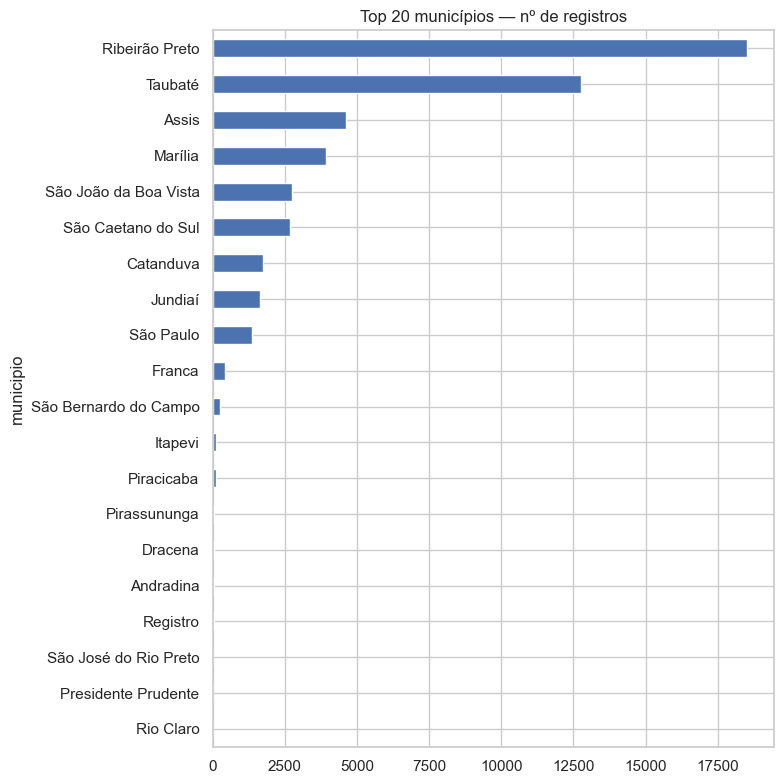

In [98]:
df["municipio"].value_counts().head(20).plot(kind="barh", figsize=(8, 8))
plt.title("Top 20 municípios — nº de registros")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [99]:
# Concentração: Ribeirão Preto e Taubaté sozinhos são ~61% dos registros
top_mun = df["municipio"].value_counts()
print((top_mun.head(2).sum() / top_mun.sum() * 100).round(1), "% dos registros vêm de Ribeirão Preto + Taubaté")
top_mun.head(10)


61.3 % dos registros vêm de Ribeirão Preto + Taubaté


municipio
Ribeirão Preto           18524
Taubaté                  12773
Assis                     4611
Marília                   3915
São João da Boa Vista     2746
São Caetano do Sul        2675
Catanduva                 1738
Jundiaí                   1637
São Paulo                 1355
Franca                     420
Name: count, dtype: int64

In [100]:
df["entidade"].value_counts().head(15)


entidade
FUNDACAO APOIO ENSINO PESQ HOSP CLINICAS RIB PRETO                                                                    18377
UNIVERSIDADE DE TAUBATE                                                                                               12754
FEMA - FUNDAÃÃO DE ENSINO DE ASSIS                                                                                   4611
FUNDACAO DE APOIO A FACULDADE DE MEDICINA DE MARILIA                                                                   3915
CENTRO UNIV.DAS FACUL. ASSOS.DE ENSINO - FAE                                                                           2746
UNIVERSIDADE MUNICIPAL DE SÃO CAETANO DO SUL - USCS                                                                   2675
INSTITUTO MUNICIPAL ENSINO SUPERIOR-IMES/FAFICA                                                                        1738
FACULDADE DE MEDICINA DE JUNDIAI                                                                                       1613

C:\Users\Vinicius Chirnev\AppData\Local\Temp\ipykernel_23188\3145431185.py:5: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Vinicius Chirnev\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


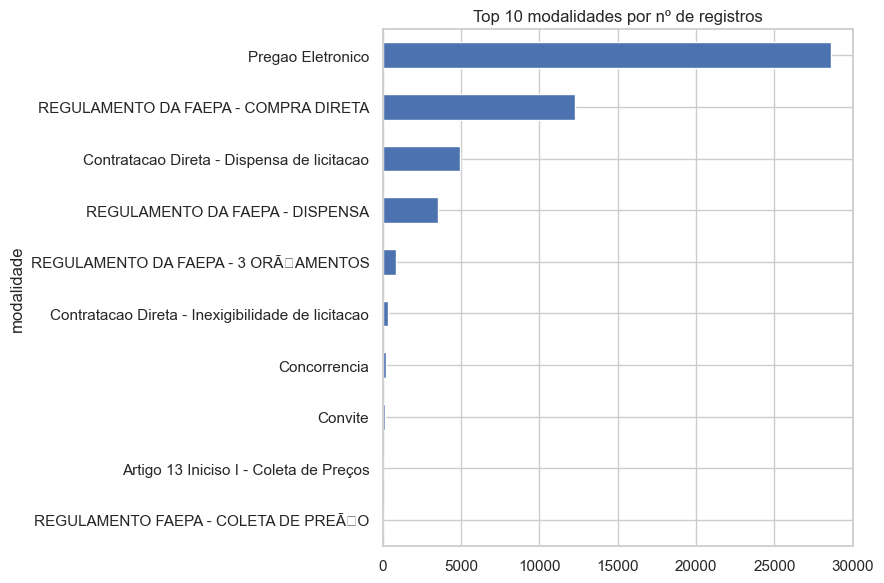

modalidade
Pregao Eletronico                                    28590
REGULAMENTO DA FAEPA - COMPRA DIRETA                 12302
Contratacao Direta - Dispensa de licitacao            4959
REGULAMENTO DA FAEPA - DISPENSA                       3542
REGULAMENTO DA FAEPA - 3 ORÃAMENTOS                   863
Contratacao Direta - Inexigibilidade de licitacao      320
Concorrencia                                           192
Convite                                                157
Artigo 13 Iniciso I - Coleta de Preços                  25
REGULAMENTO FAEPA - COLETA DE PREÃO                    18
Name: count, dtype: int64

In [101]:
top_modalidades = df["modalidade"].value_counts().head(10)
top_modalidades.plot(kind="barh", figsize=(9, 6))
plt.title("Top 10 modalidades por nº de registros")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
top_modalidades


## 6. Resultado da habilitação

Atenção: 47,9% dos registros não têm resultado de habilitação preenchido (NaN) —
provavelmente linhas de orçamento estimativo, não de propostas efetivamente recebidas.


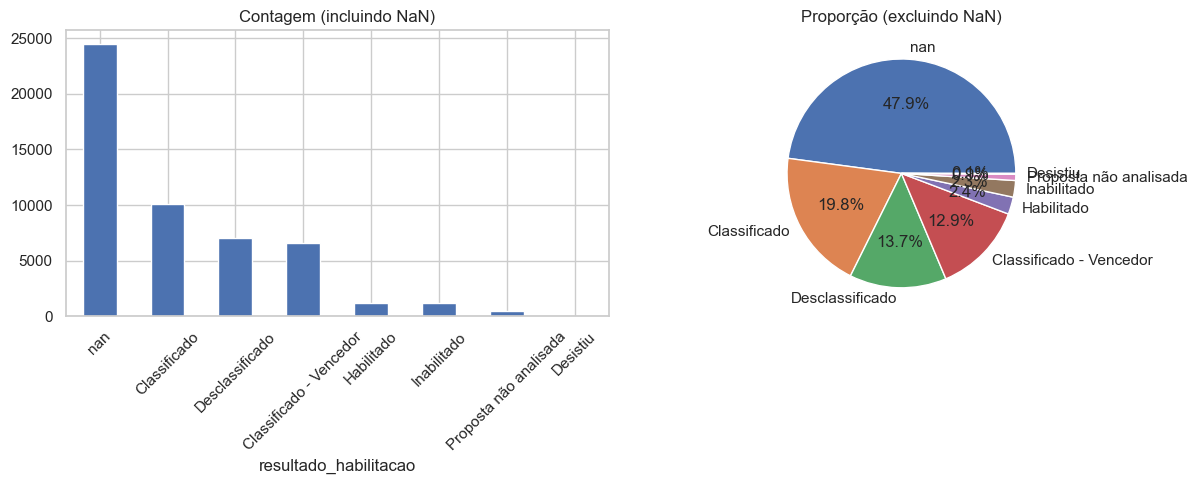

resultado_habilitacao
NaN                        24461
Classificado               10093
Desclassificado             6997
Classificado - Vencedor     6576
Habilitado                  1244
Inabilitado                 1197
Proposta não analisada       449
Desistiu                      58
Name: count, dtype: int64

In [102]:
resultado = df["resultado_habilitacao"].value_counts(dropna=False)
print("Atenção: 47,9% dos registros não têm resultado de habilitação preenchido (NaN) —")
print("provavelmente linhas de orçamento estimativo, não de propostas efetivamente recebidas.")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
resultado.plot(kind="bar", ax=ax[0])
ax[0].set_title("Contagem (incluindo NaN)")
ax[0].tick_params(axis="x", rotation=45)

resultado.dropna().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Proporção (excluindo NaN)")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()
resultado


## 7. Economicidade: valor da proposta vs valor orçado (dados limpos)

count    1.738200e+04
mean     3.798659e+06
std      7.969068e+07
min     -1.000000e+02
25%     -6.425045e+01
50%      2.198551e+02
75%      3.189118e+03
max      4.000000e+09
Name: variacao_pct, dtype: float64


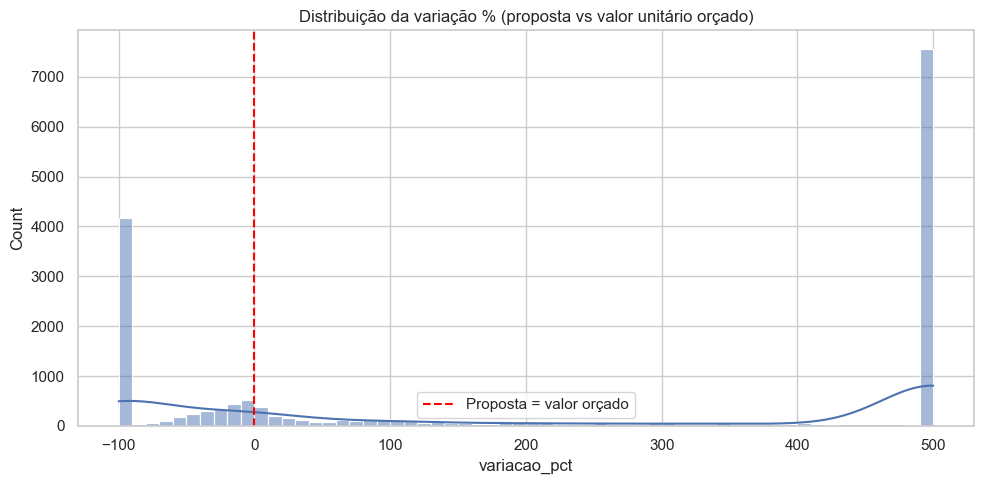

In [80]:
ref = "valor_unit_orcado_item"
df_limpo["variacao_pct"] = (df_limpo["valor_proposta"] - df_limpo[ref]) / df_limpo[ref] * 100

print(df_limpo["variacao_pct"].describe())

variacao_filtrada = df_limpo["variacao_pct"].clip(-100, 500)
plt.figure()
sns.histplot(variacao_filtrada.dropna(), bins=60, kde=True)
plt.axvline(0, color="red", linestyle="--", label="Proposta = valor orçado")
plt.title("Distribuição da variação % (proposta vs valor unitário orçado)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Ranking de gasto por município 

In [81]:
gasto_mun = (
    df_limpo.groupby("municipio")["valor_proposta"]
    .agg(total="sum", medio="mean", registros="count")
    .sort_values("total", ascending=False)
)
gasto_mun.head(15)


,total,medio,registros
municipio,,,
Ribeirão Preto,3.076888e+09,2.864887e+06,1074
Andradina,2.241363e+09,7.471210e+07,30
Pirassununga,1.089495e+09,2.136265e+07,51
São Paulo,5.731258e+08,1.500329e+06,382
Itapevi,5.470155e+08,6.753278e+06,81
Taubaté,4.907035e+08,4.752116e+04,10326
São Caetano do Sul,2.418817e+08,1.064152e+05,2273
São Bernardo do Campo,1.579046e+08,7.210256e+05,219
Jundiaí,1.224337e+08,1.200330e+05,1020


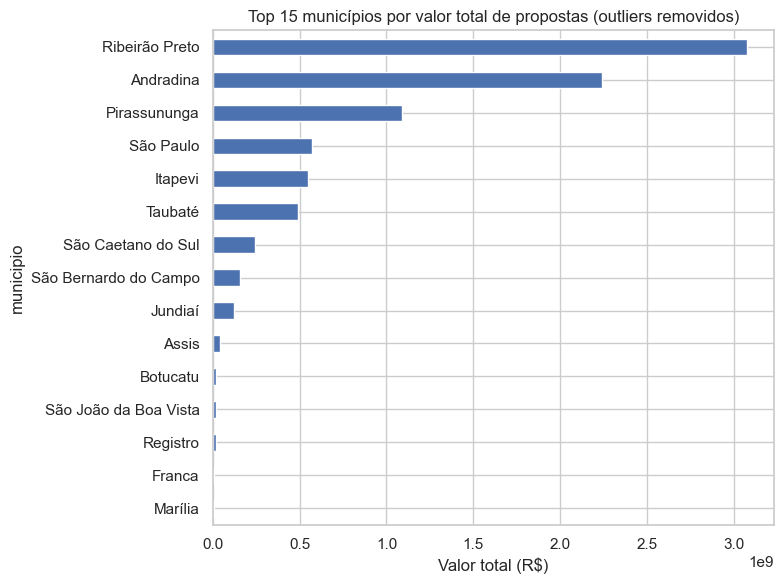

In [82]:
gasto_mun.head(15)["total"].plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 municípios por valor total de propostas (outliers removidos)")
plt.xlabel("Valor total (R$)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Concentração de fornecedores (dados limpos)

In [83]:
top_fornecedores = (
    df_limpo.groupby("nome_participante")["valor_proposta"]
    .agg(total="sum", registros="count")
    .sort_values("total", ascending=False)
    .head(15)
)
top_fornecedores


,total,registros
nome_participante,,
PRIOM TECNOLOGIA EM EQUIPAMENTOS LTDA,1.294200e+09,6
DOLLETO DOCES E SALGADOS LTDA,1.127775e+09,12
P Q SANTOS BUFFET,1.112625e+09,12
NOEM MEDICAL IMPORTACAO E EXPORTACAO DE PRODUTOS MEDICOS-HOSPITALARES LTDA,9.556328e+08,46
GRUPO TCP SERVICOS DE ALIMENTACAO LTDA,4.504517e+08,3
CORTICAL COMERCIO DE PRODUTOS CIRURGICOS LTDA,3.385184e+08,224
SIMAC MANUTENÃÃO E SERVIÃOS LTDA,3.073870e+08,3
BIGNARDI - INDUSTRIA E COMERCIO DE PAPEIS E ARTEFATOS LTDA.,1.989596e+08,2
SUNNY ALIMENTAÃÃO E SERVIÃOS LTDA,1.838304e+08,24


In [84]:
top10_valor = top_fornecedores["total"].head(10).sum()
valor_total = df_limpo["valor_proposta"].sum()
print(f"Top 10 fornecedores concentram {top10_valor/valor_total*100:.1f}% do valor total de propostas (dados limpos)")


Top 10 fornecedores concentram 71.0% do valor total de propostas (dados limpos)


## 10. Série temporal (dados limpos)

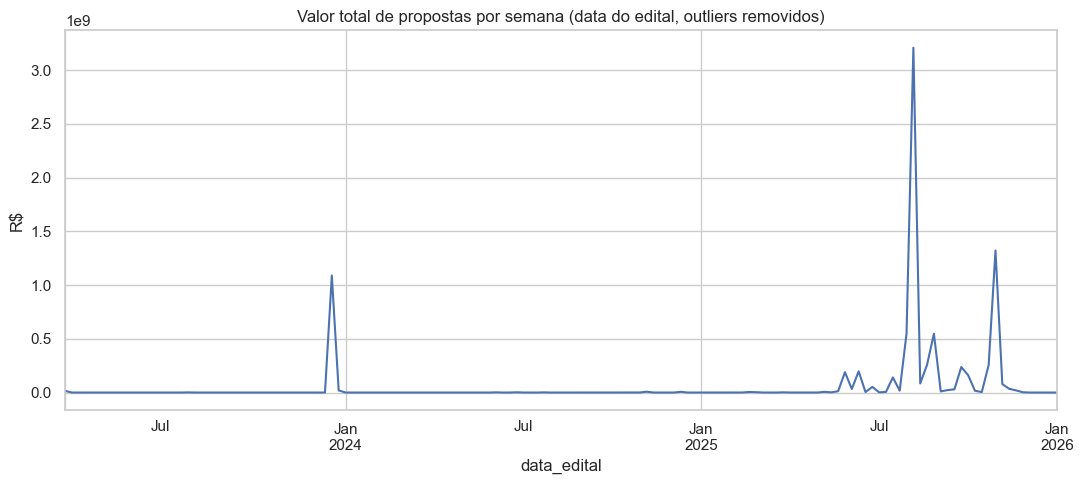

In [85]:
serie = df_limpo.dropna(subset=["data_edital"]).set_index("data_edital").resample("W")["valor_proposta"].sum()
plt.figure(figsize=(11, 5))
serie.plot()
plt.title("Valor total de propostas por semana (data do edital, outliers removidos)")
plt.ylabel("R$")
plt.tight_layout()
plt.show()


## 11. Correlação entre variáveis numéricas

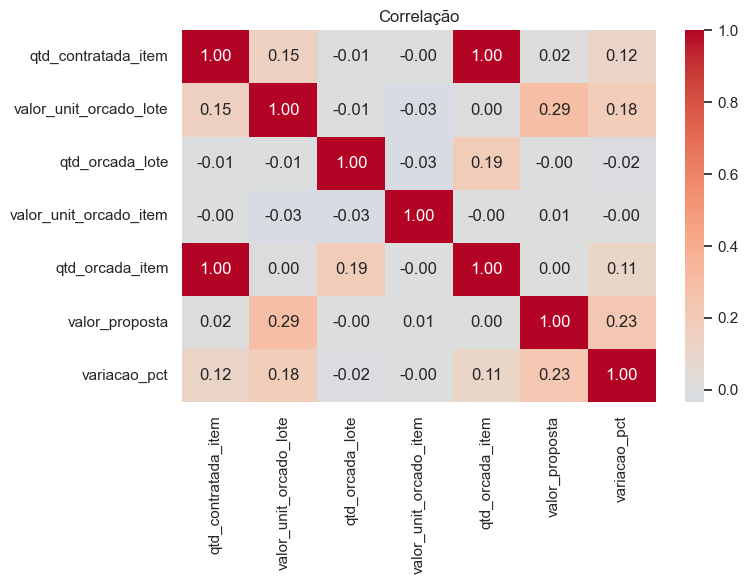

In [86]:
corr = df_limpo[colunas_numericas + ["variacao_pct"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação")
plt.tight_layout()
plt.show()


## 12. Exportar dados tratados

In [87]:
df.to_excel("licitacoes_tratado_completo.xlsx", index=False)
df_limpo.to_excel("licitacoes_tratados.xlsx", index=False)
print("Arquivos salvos.")


Arquivos salvos.


## Principais achados (resumo)

1. **Qualidade de dados é o achado nº 1**: 10 registros com `valor_proposta` acima de R$ 1 bilhão (um deles de R$ 3 trilhões) respondem por 99,9% do valor total bruto. Sem removê-los, qualquer estatística de valor fica sem sentido.
2. Mesmo limpo, há indícios de mais inconsistências pontuais entre `valor_proposta` e `valor_unit_orcado_item × quantidade` — vale investigar item a item antes de usar para auditoria/decisão.
3. **Concentração geográfica forte**: Ribeirão Preto e Taubaté somam ~61% de todos os registros — resultado esperado, já que as "entidades" nesses municípios são fundações de apoio a hospitais universitários/universidades com altíssimo volume de compras (ex.: FAEPA/HC Ribeirão Preto).
4. **Modalidade dominante**: Pregão Eletrônico é a modalidade mais usada, seguida por regulamentos internos da FAEPA (compra direta/dispensa) — sugerindo que boa parte das contratações da FAEPA segue regulamento próprio, não a Lei de Licitações padrão.
5. **~48% das linhas não têm resultado de habilitação** — provavelmente correspondem a linhas de orçamento estimativo (fase de planejamento), não a propostas efetivamente recebidas; vale confirmar esse ponto com quem gerou a base.
6. Nomes de modalidade e entidade têm perda residual de caracteres não recuperável automaticamente (ex.: `FUNDAÃÃO`, `ORÃAMENTOS`) — corrigível manualmente se necessário.